In [ ]:
# # Install package(s) for SVM
# install.packages("e1071")
# install.packages("caret")
# install.packages("kernlab")
library(e1071)
library(caret)
library(kernlab)


The downloaded binary packages are in
	/var/folders/08/y_gq7kvj36zf7tb54tsx96740000gn/T//RtmpDkcV1H/downloaded_packages

The downloaded binary packages are in
	/var/folders/08/y_gq7kvj36zf7tb54tsx96740000gn/T//RtmpDkcV1H/downloaded_packages

The downloaded binary packages are in
	/var/folders/08/y_gq7kvj36zf7tb54tsx96740000gn/T//RtmpDkcV1H/downloaded_packages


Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element


Loading required package: lattice


Attaching package: ‘kernlab’


The following object is masked from ‘package:ggplot2’:

    alpha




In [ ]:
data <- read.csv("../Pima-Indians-Diabetes-Dataset/diabetes_imputed.csv")

train_class <- read.csv("../Pima-Indians-Diabetes-Dataset/train_data_imputed.csv")
test_class <- read.csv("../Pima-Indians-Diabetes-Dataset/test_data_imputed.csv")

In [4]:
train_class$Outcome <- as.factor(train_class$Outcome)
test_class$Outcome  <- as.factor(test_class$Outcome)

In [5]:
ctrl <- trainControl(method = "cv", number = 10, classProbs = TRUE, summaryFunction = twoClassSummary)
  # cv : 10-fold cross validation

In [6]:
train_class$Outcome <- factor(train_class$Outcome, levels = c(0, 1), labels = c("No", "Yes"))
test_class$Outcome <- factor(test_class$Outcome, levels = c(0, 1), labels = c("No", "Yes"))
  # Binary (0 & 1)

In [7]:
grid <- expand.grid(sigma = c(0.001, 0.01, 0.05, 0.1, 0.5), C = c(0.1, 1, 5, 10, 20))
  # Tuning space (aka Test combinations)

,sigma,C
,<dbl>,<dbl>
12,0.05,1


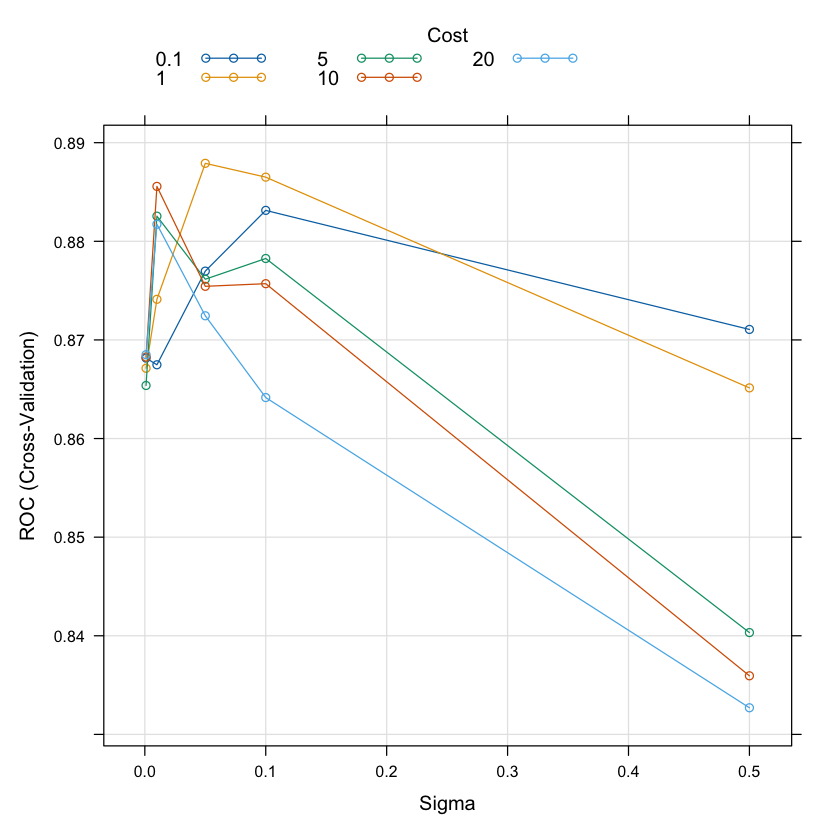

In [8]:
# Tuned SVM
svm_model <- train(
  Outcome ~ .,
  data = train_class,
  method = "svmRadial",
  metric = "ROC",
  trControl = ctrl,
  preProcess = c("center", "scale"),
  tuneGrid = grid
)
# Inspect best model
svm_model$bestTune # The sigma and C that produced the highest ROC score
plot(svm_model)
  # X-axis: sigma or C
  # Y-axis: ROC performance

In [9]:
# Predict on test set
pred <- predict(svm_model, newdata = test_class)
# Confusion matrix
confusionMatrix(pred, test_class$Outcome)

Confusion Matrix and Statistics

          Reference
Prediction No Yes
       No  91  12
       Yes 11  40
                                          
               Accuracy : 0.8506          
                 95% CI : (0.7844, 0.9029)
    No Information Rate : 0.6623          
    P-Value [Acc > NIR] : 1.102e-07       
                                          
                  Kappa : 0.6645          
                                          
 Mcnemar's Test P-Value : 1               
                                          
            Sensitivity : 0.8922          
            Specificity : 0.7692          
         Pos Pred Value : 0.8835          
         Neg Pred Value : 0.7843          
             Prevalence : 0.6623          
         Detection Rate : 0.5909          
   Detection Prevalence : 0.6688          
      Balanced Accuracy : 0.8307          
                                          
       'Positive' Class : No              
                                 

In [17]:
length(train_class$Cluster)
length(train_class$Outcome)

nrow(train_class)

[1] 0

[1] 614

[1] 614

In [ ]:
train_class$Cluster <- as.factor(train_class$Cluster)

In [16]:
# “Can cluster membership alone predict diabetes?"
# Input: Cluster (0,1,2,...)
# Output: Outcome (0/1)


# Diagnostics
table(train_class$Cluster)
table(train_class$Cluster, train_class$Outcome)

# Logistic Regression
model_kmeans_class <- glm(Outcome ~ Cluster, data = train_class, family = binomial)

# Summary
summary(model_kmeans_class)


cat("\n")


# Prediction
prob_class_km <- predict(model_kmeans_class,
                         newdata = test_class,
                         type = "response")

pred_class_km <- ifelse(prob_class_km > 0.5, "Yes", "No")
pred_class_km <- factor(pred_class_km, levels = c("No", "Yes"))

# Evaluation
mean(pred_class_km == test_class$Outcome)
#table(Predicted = pred_class_km, Actual = test_class$Outcome)
AIC(model_kmeans_class)

< table of extent 0 >

ERROR: Error in table(train_class$Cluster, train_class$Outcome): all arguments must have the same length


In [13]:
train_global$Outcome <- factor(
    train_global$Outcome,
    levels = c(0,1),
    labels = c("No","Yes")
)

test_global$Outcome <- factor(
    test_global$Outcome,
    levels = c(0,1),
    labels = c("No","Yes")
)

ERROR: Error: object 'train_global' not found


In [ ]:
class(train_global$Outcome)
levels(train_global$Outcome)

[1] "factor"

[1] "No"  "Yes"

    Linear Kernel

In [ ]:
# UNSCALED - Class
  # "Using ALL predictors except Cluster"


# Remove Outcome and Cluster
Xc_train_unscaled <- train_class[
    ,
    !(names(train_class) %in% c("Outcome", "Cluster"))
]

Xc_test_unscaled <- test_class[
    ,
    !(names(test_class) %in% c("Outcome", "Cluster"))
]

train_class_linear <- data.frame(
    Outcome = train_class$Outcome,
    Xc_train_unscaled
)

test_class_linear <- data.frame(
    Outcome = test_class$Outcome,
    Xc_test_unscaled
)

svm_class_linear <- svm(
    Outcome ~ .,
    data = train_class_linear,
    kernel = "linear"
)

pred_class_linear <- predict(
    svm_class_linear,
    newdata = test_class_linear
)

mean(pred_class_linear == test_class_linear$Outcome)

table(
    Predicted = pred_class_linear,
    Actual = test_class_linear$Outcome
)

[1] 0.8181818

         Actual
Predicted No Yes
      No  90  16
      Yes 12  36

In [ ]:
# UNSCALED - Global
Xg_train_unscaled <- train_global[
    ,
    !(names(train_global) %in% c("Outcome", "Cluster"))
]

Xg_test_unscaled <- test_global[
    ,
    !(names(test_global) %in% c("Outcome", "Cluster"))
]

train_global_linear <- data.frame(
    Outcome = train_global$Outcome,
    Xg_train_unscaled
)

test_global_linear <- data.frame(
    Outcome = test_global$Outcome,
    Xg_test_unscaled
)

svm_global_linear <- svm(
    Outcome ~ .,
    data = train_global_linear,
    kernel = "linear"
)

pred_global_linear <- predict(
    svm_global_linear,
    newdata = test_global_linear
)

mean(pred_global_linear == test_global_linear$Outcome)

table(
    Predicted = pred_global_linear,
    Actual = test_global_linear$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

In [ ]:
# SCALED - Class


Xc_train_scaled <- scale(Xc_train_unscaled)

Xc_test_scaled <- scale(
    Xc_test_unscaled,
    center = attr(Xc_train_scaled, "scaled:center"),
    scale = attr(Xc_train_scaled, "scaled:scale")
)

train_class_linear_scaled <- data.frame(
    Outcome = train_class$Outcome,
    Xc_train_scaled
)

test_class_linear_scaled <- data.frame(
    Outcome = test_class$Outcome,
    Xc_test_scaled
)

svm_class_linear_scaled <- svm(
    Outcome ~ .,
    data = train_class_linear_scaled,
    kernel = "linear"
)

pred_class_linear_scaled <- predict(
    svm_class_linear_scaled,
    newdata = test_class_linear_scaled
)

mean(pred_class_linear_scaled ==
     test_class_linear_scaled$Outcome)

table(
    Predicted = pred_class_linear_scaled,
    Actual = test_class_linear_scaled$Outcome
)

[1] 0.8181818

         Actual
Predicted No Yes
      No  90  16
      Yes 12  36

In [ ]:
# SCALED - Global


Xg_train_scaled <- scale(Xg_train_unscaled)

Xg_test_scaled <- scale(
    Xg_test_unscaled,
    center = attr(Xg_train_scaled, "scaled:center"),
    scale = attr(Xg_train_scaled, "scaled:scale")
)

train_global_linear_scaled <- data.frame(
    Outcome = train_global$Outcome,
    Xg_train_scaled
)

test_global_linear_scaled <- data.frame(
    Outcome = test_global$Outcome,
    Xg_test_scaled
)

svm_global_linear_scaled <- svm(
    Outcome ~ .,
    data = train_global_linear_scaled,
    kernel = "linear"
)

pred_global_linear_scaled <- predict(
    svm_global_linear_scaled,
    newdata = test_global_linear_scaled
)

mean(pred_global_linear_scaled ==
     test_global_linear_scaled$Outcome)

table(
    Predicted = pred_global_linear_scaled,
    Actual = test_global_linear_scaled$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

    Radial Kernel

    CLASS

In [ ]:
# UNSCALED
Xc_train_unscaled <- train_class[
    ,
    !(names(train_class) %in% c("Outcome", "Cluster"))
]
Xc_test_unscaled <- test_class[
    ,
    !(names(test_class) %in% c("Outcome", "Cluster"))
]

train_class_unscaled <- data.frame(
    Outcome = as.factor(train_class$Outcome),
    Xc_train_unscaled
)
test_class_unscaled <- data.frame(
    Outcome = as.factor(test_class$Outcome),
    Xc_test_unscaled
)

svm_class_radial <- svm(
    Outcome ~ .,
    data = train_class_unscaled,
    kernel = "radial"
)
pred_class_radial <- predict(
    svm_class_radial,
    newdata = test_class_unscaled
)


mean(pred_class_radial == test_class_unscaled$Outcome)
table(
    Predicted = pred_class_radial,
    Actual = test_class_unscaled$Outcome
)

[1] 0.8636364

         Actual
Predicted No Yes
      No  93  12
      Yes  9  40

In [ ]:
# SCALED
Xc_train_scaled <- scale(Xc_train_unscaled)
Xc_test_scaled <- scale(
    Xc_test_unscaled,
    center = attr(Xc_train_scaled, "scaled:center"),
    scale = attr(Xc_train_scaled, "scaled:scale")
)

train_class_scaled <- data.frame(
    Outcome = as.factor(train_class$Outcome),
    Xc_train_scaled
)
test_class_scaled <- data.frame(
    Outcome = as.factor(test_class$Outcome),
    Xc_test_scaled
)

svm_class_radial_scaled <- svm(
    Outcome ~ .,
    data = train_class_scaled,
    kernel = "radial"
)
pred_class_radial_scaled <- predict(
    svm_class_radial_scaled,
    newdata = test_class_scaled
)


mean(pred_class_radial_scaled ==
     test_class_scaled$Outcome)
table(
    Predicted = pred_class_radial_scaled,
    Actual = test_class_scaled$Outcome
)

[1] 0.8636364

         Actual
Predicted No Yes
      No  93  12
      Yes  9  40

    GLOBAL

In [ ]:
# UNSCALED
Xg_train_unscaled <- train_global[
    ,
    !(names(train_global) %in% c("Outcome", "Cluster"))
]
Xg_test_unscaled <- test_global[
    ,
    !(names(test_global) %in% c("Outcome", "Cluster"))
]

train_global_unscaled <- data.frame(
    Outcome = as.factor(train_global$Outcome),
    Xg_train_unscaled
)
test_global_unscaled <- data.frame(
    Outcome = as.factor(test_global$Outcome),
    Xg_test_unscaled
)

svm_global_radial <- svm(
    Outcome ~ .,
    data = train_global_unscaled,
    kernel = "radial"
)
pred_global_radial <- predict(
    svm_global_radial,
    newdata = test_global_unscaled
)


mean(pred_global_radial ==
     test_global_unscaled$Outcome)
table(
    Predicted = pred_global_radial,
    Actual = test_global_unscaled$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

In [ ]:
# SCALED
Xg_train_scaled <- scale(Xg_train_unscaled)
Xg_test_scaled <- scale(
    Xg_test_unscaled,
    center = attr(Xg_train_scaled, "scaled:center"),
    scale = attr(Xg_train_scaled, "scaled:scale")
)

train_global_scaled <- data.frame(
    Outcome = as.factor(train_global$Outcome),
    Xg_train_scaled
)
test_global_scaled <- data.frame(
    Outcome = as.factor(test_global$Outcome),
    Xg_test_scaled
)

svm_global_radial_scaled <- svm(
    Outcome ~ .,
    data = train_global_scaled,
    kernel = "radial"
)
pred_global_radial_scaled <- predict(
    svm_global_radial_scaled,
    newdata = test_global_scaled
)


mean(pred_global_radial_scaled ==
     test_global_scaled$Outcome)
table(
    Predicted = pred_global_radial_scaled,
    Actual = test_global_scaled$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

In [ ]:
svm_class_radial


Call:
svm(formula = Outcome ~ ., data = train_class_unscaled, kernel = "radial")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  307
